In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import mean_squared_error, f1_score, recall_score, precision_score, classification_report
from sklearn.model_selection import train_test_split, KFold, cross_val_score

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

import optuna

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

## 1. Load Data

In [2]:
ori_tr_data = pd.read_csv("/kaggle/input/tahap-penyisihan-oq-dataquestua/train.csv")
ori_ts_data = pd.read_csv("/kaggle/input/tahap-penyisihan-oq-dataquestua/test.csv")

ori_tr_data.head()

,datetime,datetime_iso,time-zone,temp,visibility,d_point,feels,min_temp,max_temp,prssr,sea_level,grnd_level,hum,wind_spd,wind_deg,rain_1h,rain_3h,snow_1h,snow_3h,clouds
0,283996800,1979-01-01 00:00:00+00:00,28800,24.75 Celcius,NaN,23.89 C,25.76 C,24.28,25.22°C,1012,undetermined,NaN,95,0.82,320.0 °,zero,0,NaN,NaN,100
1,284000400,1979-01-01 01:00:00+00:00,28800,24.58 C,NaN,23.73 C,25.57 C,23.99 C,25.26 C,1012,NaN,NaN,95,0.96 m/s,338.0°,0,0,0,0,100
2,284004000,1979-01-01 02:00:00+00:00,28800,26.6 Celcius,unidentified,24.06 C,26.6 C,26.1 C,27.39,1012,NaN,undetermined,86,1.22 m/s,339.0°,0,volume:zero,NaN,NaN,99
3,284007600,1979-01-01 03:00:00+00:00,28800,27.31 Celcius,NaN,24.37 C,30.9 C,26.59,28.36 C,1012,NaN,undetermined,84,1.08 m/s,342,0.13,nol,0,NaN,94
4,284011200,1979-01-01 04:00:00+00:00,28800,27.41,NaN,25.05 C,31.54 C,26.58 C,28.31 °C,1011,NaN,undetermined,87,0.86,336.0°,0.34,nol,NaN,0,100


In [3]:
print(ori_tr_data.shape)
ori_tr_data.info()

(341880, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341880 entries, 0 to 341879
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   datetime      341880 non-null  int64 
 1   datetime_iso  341880 non-null  object
 2   time-zone     341880 non-null  int64 
 3   temp          341880 non-null  object
 4   visibility    51112 non-null   object
 5   d_point       341880 non-null  object
 6   feels         341880 non-null  object
 7   min_temp      341880 non-null  object
 8   max_temp      341880 non-null  object
 9   prssr         341880 non-null  object
 10  sea_level     192964 non-null  object
 11  grnd_level    192919 non-null  object
 12  hum           341880 non-null  object
 13  wind_spd      341880 non-null  object
 14  wind_deg      341880 non-null  object
 15  rain_1h       341880 non-null  object
 16  rain_3h       192329 non-null  object
 17  snow_1h       192696 non-null  object
 18  snow_3h    

## 2. Data Cleaning and Preprocessing

In [4]:
ori_tr_data[ori_tr_data["rain_1h"] == "-1mm"]

datetime               datetime_iso  time-zone           temp  \
17       284058000  1979-01-01 17:00:00+00:00      28800        24.36 C   
44       284155200  1979-01-02 20:00:00+00:00      28800        23.67 C   
86       284306400  1979-01-04 14:00:00+00:00      28800       26.36  C   
323      285159600  1979-01-14 11:00:00+00:00      28800        26.23 C   
374      285343200  1979-01-16 14:00:00+00:00      28800         24.7 C   
...            ...                        ...        ...            ...   
340862  1511100000  2017-11-19 14:00:00+00:00      28800       26.51  C   
341435  1513162800  2017-12-13 11:00:00+00:00      28800       28.21 °C   
341478  1513317600  2017-12-15 06:00:00+00:00      28800        30.67 C   
341522  1513476000  2017-12-17 02:00:00+00:00      28800        29.06 C   
341865  1514710800  2017-12-31 09:00:00+00:00      28800  29.19 Celcius   

       visibility  d_point     feels min_temp max_temp        prssr  \
17            NaN    24.19   25.44°C  23.43 C    25.12  1012.0 hPa.   
44            NaN    23.33     24.65    22.98   24.4 C         1011   
86            NaN    25.67   26.36 C  25.49 C  27.43 C         1011   
323           NaN  25.54°C  26.23 °C    24.91       27   1010.0 hPa   
374           NaN  24.02 C     25.73  24.01 C    25.75   1013.0 hPa   
...           ...      ...       ...      ...      ...          ...   
340862        NaN    25.99     26.51  25.59 C  29.02 C         1009   
341435        NaN  25.84 C   33.86 C  27.49 C  28.93 C   1009.0 hPa   
341478        NaN  24.08 C     36.17  29.02 C  31.34 C         1009   
341522        NaN    24.61   34.26 C    28.02    29.79         1012   
341865        NaN   26.0 C   35.98 C    28.42  30.06 C  5055.15 hPa   

           sea_level    grnd_level     hum  wind_spd wind_deg rain_1h  \
17               NaN           NaN      99   0.8 m/s      296    -1mm   
44               NaN   unspecified  98.00%  0.62 m/s      308    -1mm   
86      undetermined  undetermined      96      0.78   311.0°    -1mm   
323     undetermined           NaN      96      0.66   304.0°    -1mm   
374     undetermined           NaN      96      1.24   337.0°    -1mm   
...              ...           ...     ...       ...      ...     ...   
340862  undetermined           NaN      97      0.38   123.0°    -1mm   
341435  not recorded           NaN      87  5.33 m/s      292    -1mm   
341478  undetermined  undetermined      68      2.24      256    -1mm   
341522  not_recorded           NaN      77  2.99 m/s  218.0 °    -1mm   
341865  undetermined           NaN      83   1.0 m/s      160    -1mm   

            rain_3h snow_1h snow_3h   clouds  
17              NaN     0mm       0  100.00%  
44              NaN       0       0      100  
86              NaN     NaN     NaN       99  
323               0     NaN     NaN       99  
374             NaN     NaN     NaN       99  
...             ...     ...     ...      ...  
340862      no-rain     NaN     NaN       48  
341435  volume:zero       0       0      100  
341478          NaN       0    0 mm      100  
341522      no_rain       0       0       92  
341865  0 milimeter       0       0   97.00%  

[5442 rows x 20 columns]

In [5]:
def cleaning(train_data, test_data):
    train, test = train_data.copy(), test_data.copy()
    train = train[train["rain_1h"] != "-1mm"]   # filter -1 mm target rain
    
    uncleaned_cols = ['visibility', 'sea_level', 'grnd_level', 'snow_1h', 'snow_3h', 'datetime', 'time-zone', 'rain_3h',
                     'datetime_iso']
    for col in train.drop(uncleaned_cols, axis=1).columns:
        try:
            if col == "rain_1h":
                train["rain_1h"] = train["rain_1h"].apply(lambda row: 0 if row == "zero" else row)
                
            train[col] = train[col].str.replace(r'[^0-9.]+|\.+$', '', regex=True)
            
            if col != 'rain_1h':
                train[col] = train[col].astype('float')
                
                test[col] = test[col].str.replace(r'[^0-9.]+|\.+$', '', regex=True)
                test[col] = test[col].astype('float')
        except:
            print(col)

#     train = train.loc[~(train.rain_1h == '')].reset_index(drop=True)
#     train["rain_1h"] = train["rain_1h"].astype(float)
    train["datetime_iso"] = pd.to_datetime(train["datetime_iso"])
    
    train = train.drop(uncleaned_cols[:-1], axis=1) 
    test = test.drop(uncleaned_cols[:-1], axis=1)
#     train = train[train["rain_1h"].notna()].reset_index(drop=True)
    return train, test

tr_data, ts_data = cleaning(ori_tr_data, ori_ts_data)

In [6]:
def preprocessing(_df:pd.DataFrame) -> pd.DataFrame:
    df = _df.copy()
    
    drop = ['visibility', 'sea_level', 'grnd_level', 'snow_1h', 'snow_3h', 'datetime', 'time-zone', 'rain_3h',
                     'datetime_iso']
    
    for col in df.drop(columns=drop).columns:
        print(col)
        df[col] = df[col].str.replace(r'[^0-9.-]+|\.+$', '', regex=True)
        df[col] = df[col].replace('', np.nan)
        df[col] = df[col].astype('float')
            
#     if 'rain_1h' in df.columns:
#         df = df.loc[~((df.rain_1h == '') | (df.rain_1h == -1))].dropna()
    
#     df = df.loc[~((df.index > '2007-07-23') & (df.index < '2007-07-25'))]
    
    limits = {
        'temp': (20, 50),
        'd_point': (10, 50),
        'feels': (20, 50),
        'min_temp': (10, 50),
        'max_temp': (20, 50),
        'prssr': (900, 1100),
        'hum': (0, 100),
        'clouds': (0, 100),
        'wind_deg': (0, 360),
        'wind_spd': (0, 100)
    }
    
    for col, (lower, upper) in limits.items():
        df.loc[~((df[col] > lower) & (df[col] < upper)), col] = np.nan
        
    df.ffill(inplace=True)
    df.bfill(inplace=True)
    
    df = df.drop(drop[:-1], axis=1)
    df["datetime_iso"] = pd.to_datetime(df["datetime_iso"])
    return df

In [7]:
tr_data, ts_data = preprocessing(ori_tr_data), preprocessing(ori_ts_data)
tr_data = tr_data[tr_data["rain_1h"] >= 0]

temp
d_point
feels
min_temp
max_temp
prssr
hum
wind_spd
wind_deg
rain_1h
clouds
temp
d_point
feels
min_temp
max_temp
prssr
hum
wind_spd
wind_deg
clouds


In [8]:
tr_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 335765 entries, 0 to 341879
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype              
---  ------        --------------   -----              
 0   datetime_iso  335765 non-null  datetime64[ns, UTC]
 1   temp          335765 non-null  float64            
 2   d_point       335765 non-null  float64            
 3   feels         335765 non-null  float64            
 4   min_temp      335765 non-null  float64            
 5   max_temp      335765 non-null  float64            
 6   prssr         335765 non-null  float64            
 7   hum           335765 non-null  float64            
 8   wind_spd      335765 non-null  float64            
 9   wind_deg      335765 non-null  float64            
 10  rain_1h       335765 non-null  float64            
 11  clouds        335765 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(11)
memory usage: 33.3 MB


In [9]:
tr_data.head()

,datetime_iso,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds
0,1979-01-01 00:00:00+00:00,24.75,23.89,25.76,24.28,25.22,1012.0,95.0,0.82,320.0,0.00,99.0
1,1979-01-01 01:00:00+00:00,24.58,23.73,25.57,23.99,25.26,1012.0,95.0,0.96,338.0,0.00,99.0
2,1979-01-01 02:00:00+00:00,26.60,24.06,26.60,26.10,27.39,1012.0,86.0,1.22,339.0,0.00,99.0
3,1979-01-01 03:00:00+00:00,27.31,24.37,30.90,26.59,28.36,1012.0,84.0,1.08,342.0,0.13,94.0
4,1979-01-01 04:00:00+00:00,27.41,25.05,31.54,26.58,28.31,1011.0,87.0,0.86,336.0,0.34,94.0


## 3. Exploratory Data Analysis

In [10]:
tr_data.describe()

,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds
count,335765.000000,335765.000000,335765.000000,335765.000000,335765.000000,335765.000000,335765.000000,335765.000000,335765.000000,335765.000000,335765.000000
mean,26.689449,24.574673,29.336144,25.924877,27.692027,1009.916197,88.822325,1.473384,199.059945,0.367073,84.793213
std,2.176797,0.980658,4.340717,2.119909,2.214114,1.850545,9.377727,1.103896,95.404571,0.948923,22.360060
min,21.550000,14.490000,22.350000,14.120000,22.370000,1001.000000,29.000000,0.010000,1.000000,0.000000,1.000000
25%,24.970000,23.940000,25.990000,24.230000,25.950000,1009.000000,83.000000,0.880000,148.000000,0.000000,81.000000
50%,26.170000,24.550000,26.640000,25.440000,27.220000,1010.000000,92.000000,1.260000,202.000000,0.000000,96.000000
75%,28.270000,25.210000,33.170000,27.530000,29.180000,1011.000000,96.000000,1.800000,275.000000,0.240000,99.000000
max,36.580000,29.310000,41.520000,34.000000,39.720000,1017.000000,99.000000,25.000000,359.000000,27.100000,99.000000


In [11]:
def plot_dist(df: pd.DataFrame, ts_df: pd.DataFrame):
    selected_df = df.drop(["rain_1h"], axis=1).select_dtypes(include=np.number)
    selected_ts_df = ts_df.select_dtypes(include=np.number)
    count_cols = len(selected_df.columns)
    num_cols, num_rows = 3, count_cols // 3 + 1
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 15))
    axes = axes.ravel()
    for i, col in enumerate(selected_df.columns):
        sns.distplot(selected_df[col], ax=axes[i], label="Train")
        sns.distplot(selected_ts_df[col], ax=axes[i], label="Test")
        axes[i].set_title(f'Distribution {i+1}: {col}')
        axes[i].legend()
    plt.tight_layout()
    plt.legend()
    plt.savefig("Train vs Test Distribution.jpg")
    plt.show()

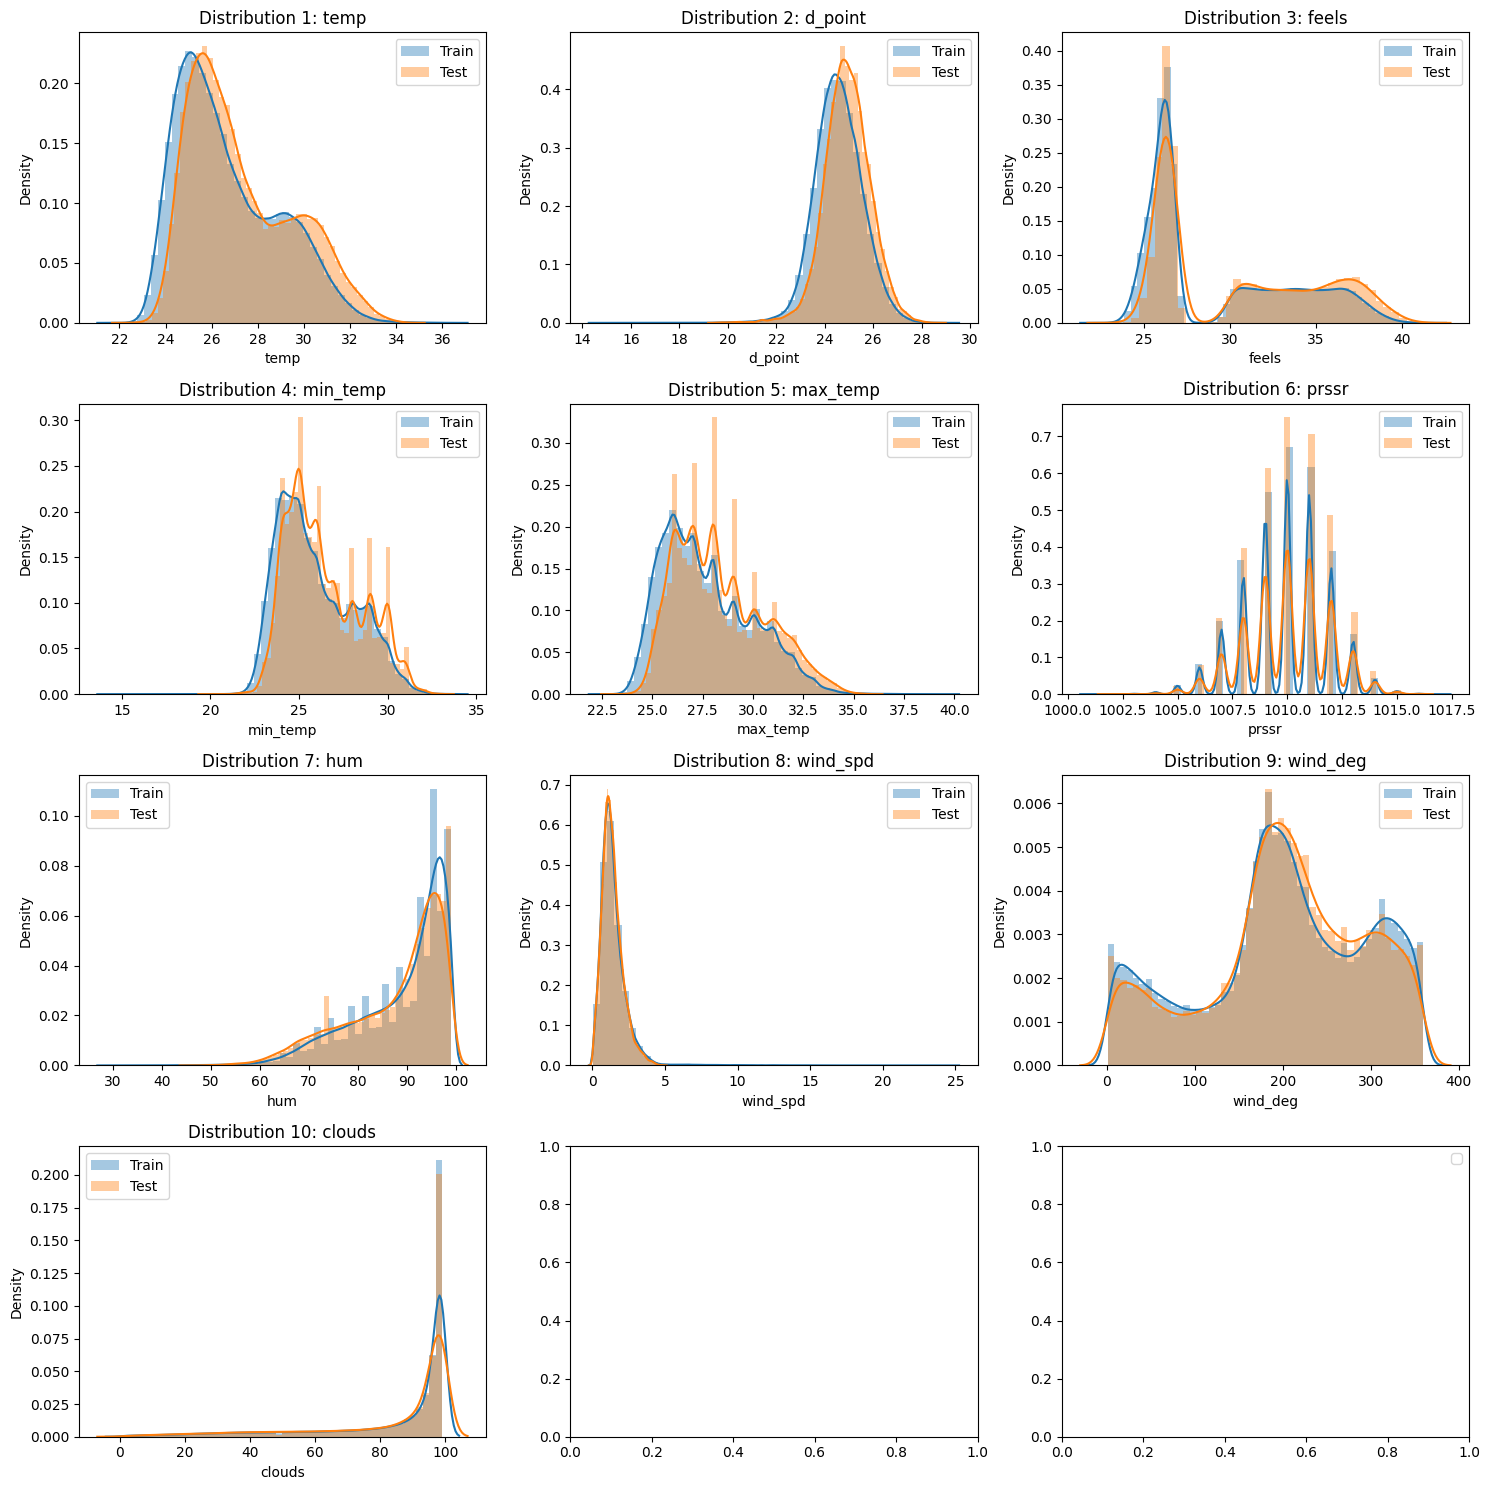

In [12]:
plot_dist(tr_data, ts_data)

In [13]:
# idx = tr_data["rain_1h"].idxmax()
idx = 36296

sample_df = tr_data.iloc[[i for i in range(idx-48, idx+2)]]
# sample_eng = tr_eng.iloc[[i for i in range(idx-48, idx+2)]]

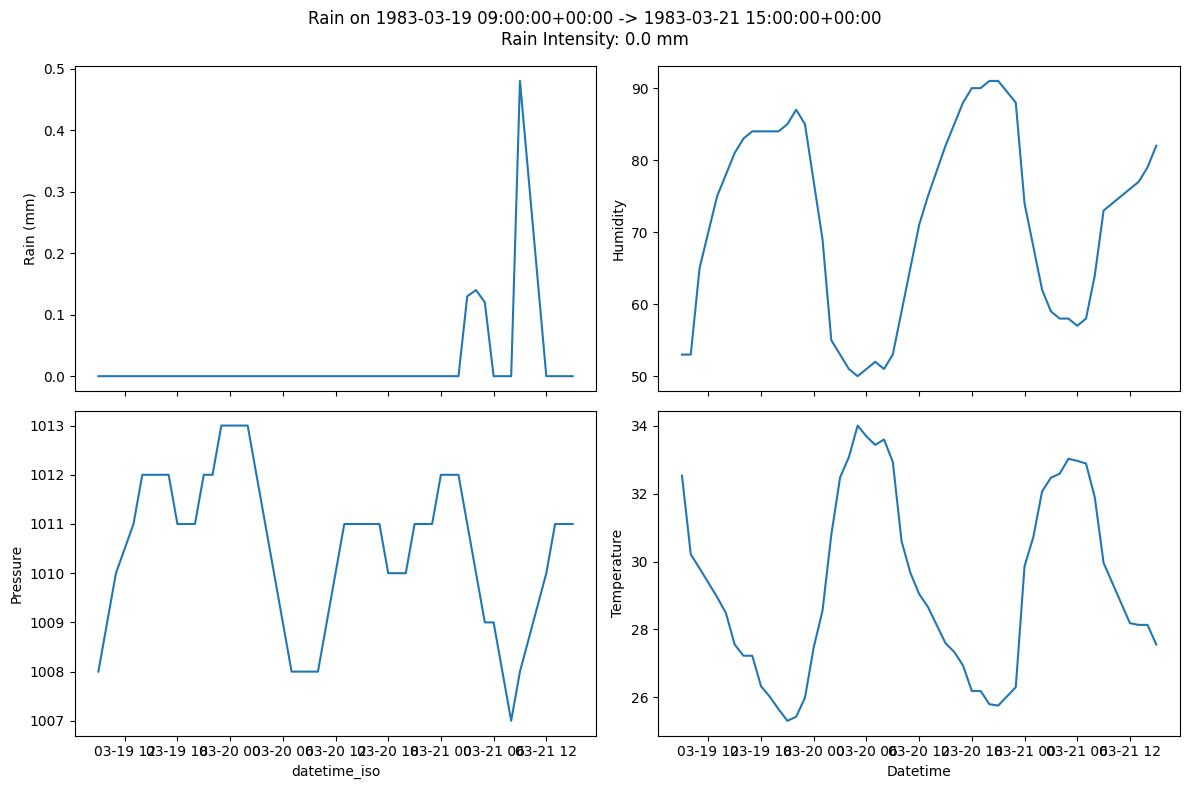

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
fig.suptitle(f"Rain on {str(sample_df.iloc[0]['datetime_iso'])} -> {str(sample_df.iloc[-1]['datetime_iso'])}\nRain Intensity: {str(sample_df.iloc[-2]['rain_1h'])} mm")

sns.lineplot(x=sample_df["datetime_iso"], y=sample_df["rain_1h"], ax=axes[0, 0])
axes[0, 0].set_ylabel("Rain (mm)")

sns.lineplot(x=sample_df["datetime_iso"], y=sample_df["hum"], ax=axes[0, 1])
axes[0, 1].set_ylabel("Humidity")

sns.lineplot(x=sample_df["datetime_iso"], y=sample_df["prssr"], ax=axes[1, 0])
axes[1, 0].set_ylabel("Pressure")

sns.lineplot(x=sample_df["datetime_iso"], y=sample_df["temp"], ax=axes[1, 1])
axes[1, 1].set_ylabel("Temperature")

plt.xlabel("Datetime")

plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [57]:
lookback_cols = ['temp',
                 'diff_temp',
                 'd_point',
                 'prssr',
                 'hum',
                 'wind_spd',
                 'wind_deg',
                 'clouds']

def time_features(_df: pd.DataFrame) -> pd.DataFrame:
    df = _df.copy()
    
    hour = df["datetime_iso"].dt.hour
    month = df["datetime_iso"].dt.month
    year = df["datetime_iso"].dt.year
    day_year = df["datetime_iso"].dt.day_of_year

    for time, col in zip([hour, month, year, day_year], ['hour', 'month', 'year', 'day_year']):
        time_range = {
            'hour': 24,
            'month': 30,
            'year': 2023,
            'day_year': 366,
        }
        df[f'{col}_sin'] = np.sin(time * (2 * np.pi / time_range[col]))
        df[f'{col}_cos'] = np.cos(time * (2 * np.pi / time_range[col]))
    
    return df

def wind_features(_df: pd.DataFrame) -> pd.DataFrame:
    df = _df.copy()
    wv = df.pop('wind_spd')
    wd_rad = df.pop('wind_deg')*np.pi / 180

    # Calculate the wind x and y components.
    df['wind_x'] = wv*np.cos(wd_rad)
    df['wind_y'] = wv*np.sin(wd_rad)
    
    return df

def diff_target_feat(_df: pd.DataFrame) -> pd.DataFrame:
    df = _df.copy()
    
    for col in lookback_cols:
        if col in ['rain_1h'] or 'sin' in col or 'cos' in col: continue
        for n_diff in range(1, 9):
            df[f'{col}_backdiff{n_diff}'] = df[col].diff(periods=n_diff)
            df[f'{col}_forwdiff{n_diff}'] = df[col] - df[col].shift(-n_diff).fillna(0)
       
    df.fillna(0, inplace=True)
    
    return df

def date_features(_df: pd.DataFrame):
    df = _df.copy()
    df["month"] = df["datetime_iso"].dt.month
#     df["week"] = df["datetime_iso"].dt.week
    df["day"] = df["datetime_iso"].dt.day
    df["day"] = df["datetime_iso"].dt.day_of_year
    df["quarter"] = df["datetime_iso"].dt.quarter
    df["hour"] = df["datetime_iso"].dt.hour
    return df

In [58]:
def agg_feat(_data: pd.DataFrame, list_diff):
    data = _data.copy() 
    agg_lst = ["min", "max", "mean", "var", "ptp"] + [f"p{i}" for i in range(10, 100, 10)]
#     agg_lst = ["min", "max", "mean", "var", "ptp"] + [f""]
    
    for diff in list_diff:
        agg_dict = {f"{stat}_{col}_lb{diff}": [] for stat in agg_lst for col in lookback_cols}
        data = data.iloc[[i for i in range(diff, len(data))]].reset_index(drop=True)
        tr_val = _data.values
        
        window_idx = (np.array(
                        [[i  for i in range(curr_idx - diff, curr_idx + 1)] 
                             for curr_idx in range(diff, len(_data))]
                              ))
        
        for i, col in tqdm(enumerate(_data.columns), total=len(_data.columns)):
            if col not in ["datetime_iso", "unique_id", "rain_1h"]:
                window_val = tr_val[window_idx, i]

                agg_dict[f"min_{col}_lb{diff}"] = np.min(window_val, axis=1)
                agg_dict[f"max_{col}_lb{diff}"] = np.max(window_val, axis=1)
                agg_dict[f"mean_{col}_lb{diff}"] = np.mean(window_val, axis=1)
                agg_dict[f"ptp_{col}_lb{diff}"] = np.ptp(window_val, axis=1)
                agg_dict[f"var_{col}_lb{diff}"] = np.var(window_val, axis=1)
                for k in range(10, 100, 10):
                    agg_dict[f"p{k}_{col}_lb{diff}"] = np.percentile(window_val, k, axis=1)

        data = pd.concat([data.reset_index(drop=True), pd.DataFrame(agg_dict)], axis=1)
    return data


def transpose_feat(_data: pd.DataFrame, n_hour: int):
    data = _data.copy()
    transposed_lst = ([f"{col}_{i}pasthour" 
                      for col in _data.columns 
                      for i in range(n_hour, 0, -1) 
                      if col not in ["datetime_iso", "unique_id", "rain_1h"]])
    
    data = data.iloc[[i for i in range(n_hour, len(data))]].reset_index(drop=True)
    tr_val = _data.values
    
    window_idx = (np.array(
                        [[i for i in range(curr_idx - n_hour, curr_idx)] 
                            for curr_idx in range(n_hour, len(_data))]
                              ))
    
    np_transposed = np.array([[0] for i in range(len(data))])
    for i, col in tqdm(enumerate(_data.columns), total=len(_data.columns)):
        if col not in ["datetime_iso", "unique_id", "rain_1h"]:
            transposed_col = tr_val[window_idx, i]
            np_transposed = np.hstack((np_transposed, transposed_col))
    df_transposed = pd.DataFrame(np_transposed[:, 1:], columns=transposed_lst)
            
    return df_transposed
   

tr_data.rename(columns={"min_temp":"min_temp_real",
                        "max_temp":"max_temp_real"}, inplace=True)

ts_data.rename(columns={"min_temp":"min_temp_real",
                        "max_temp":"max_temp_real"}, inplace=True)    
    
# tr_diff = opt_diff_feat(tr_data, [8])
# ts_diff = opt_diff_feat(ts_data, [8])

# tr_diff = tr_data.copy()
# ts_diff = ts_data.copy()

In [59]:
tr_data = tr_data[tr_data["rain_1h"].notna()].reset_index(drop=True)
all_diff = pd.concat([tr_data, ts_data])
all_diff["diff_temp"] = all_diff["max_temp_real"] - all_diff["min_temp_real"]

all_agg = agg_feat(all_diff, [12])
# all_transposed = transpose_feat(all_diff, 6)
# all_feats = pd.concat([all_agg, all_transposed], axis=1)
# print(all_feats.shape)
# all_feats.head()
all_diff = all_agg.copy()

In [60]:
=all_diff["datetime_iso"] = pd.to_datetime(all_diff["datetime_iso"])=

all_diff = all_diff.loc[~(all_diff.rain_1h == '')].reset_index(drop=True)
all_diff["rain_1h"] = all_diff["rain_1h"].astype(float)=

In [61]:
ts_diff = all_diff[all_diff["rain_1h"].isna()].reset_index(drop=True)
tr_diff = all_diff[all_diff["rain_1h"].notna()].reset_index(drop=True)

tr_rows = tr_diff.shape[0]
ts_diff.shape, tr_diff.shape

((49368, 167), (335753, 167))

In [62]:
=all_eng  = (
    all_diff
        .pipe(date_features)
        .pipe(time_features)
        .pipe(diff_target_feat)
        .pipe(wind_features)
        )

In [63]:
all_eng

,datetime_iso,temp,d_point,feels,min_temp_real,max_temp_real,prssr,hum,rain_1h,clouds,diff_temp,min_temp_lb12,min_diff_temp_lb12,min_d_point_lb12,min_prssr_lb12,min_hum_lb12,min_wind_spd_lb12,min_wind_deg_lb12,min_clouds_lb12,max_temp_lb12,max_diff_temp_lb12,max_d_point_lb12,max_prssr_lb12,max_hum_lb12,max_wind_spd_lb12,max_wind_deg_lb12,max_clouds_lb12,mean_temp_lb12,mean_diff_temp_lb12,mean_d_point_lb12,mean_prssr_lb12,mean_hum_lb12,mean_wind_spd_lb12,mean_wind_deg_lb12,mean_clouds_lb12,var_temp_lb12,var_diff_temp_lb12,var_d_point_lb12,var_prssr_lb12,var_hum_lb12,var_wind_spd_lb12,var_wind_deg_lb12,var_clouds_lb12,ptp_temp_lb12,ptp_diff_temp_lb12,ptp_d_point_lb12,ptp_prssr_lb12,ptp_hum_lb12,ptp_wind_spd_lb12,ptp_wind_deg_lb12,ptp_clouds_lb12,p10_temp_lb12,p10_diff_temp_lb12,p10_d_point_lb12,p10_prssr_lb12,p10_hum_lb12,p10_wind_spd_lb12,p10_wind_deg_lb12,p10_clouds_lb12,p20_temp_lb12,p20_diff_temp_lb12,p20_d_point_lb12,2.13,-24.0,211.0,-24.0,211.0,-24.0,211.0,-28.0,211.0,-28.0,211.0,-28.0,211.0,-11.0,211.0,-11.0,211.0,17.0,87.0,17.0,87.0,17.0,87.0,3.0,87.0,3.0,87.0,3.0,87.0,-11.0,87.0,-11.0,87.0,-1.825766,-1.097031


In [64]:
all_eng = all_eng.drop(["datetime_iso"], axis=1)
tr_eng = all_eng.iloc[:tr_rows].reset_index(drop=True)
ts_eng = all_eng.iloc[tr_rows:].reset_index(drop=True)
ts_eng.shape, tr_eng.shape

((49368, 306), (335753, 306))

In [65]:
obj_cols = tr_eng.select_dtypes("object").columns 
prec_cols = [x for x in tr_eng.columns if "mean" in x or "var" in x]

for col in obj_cols:
    if col in prec_cols:
        tr_eng[col] = tr_eng[col].astype(np.float64)
    else:
        tr_eng[col] = tr_eng[col].astype(np.float32)

In [66]:
obj_cols = ts_eng.select_dtypes("object").columns 
for col in obj_cols:
    if col in prec_cols:
        ts_eng[col] = ts_eng[col].astype(np.float64)
    else:
        ts_eng[col] = ts_eng[col].astype(np.float32)

In [34]:
def cls_label_rain(row):
    if row == 0:
        return 0
    elif row > 0 and row <= 2:
        return 1
    elif row > 2:
        return 2

cls_tr_data = tr_eng.copy()
cls_tr_data["cls_rain"] =  cls_tr_data["rain_1h"].apply(cls_label_rain)
cls_tr_data = cls_tr_data.drop(["rain_1h"], axis=1)
cls_tr_data["cls_rain"].value_counts()

cls_rain
0    201851
1    115636
2     18266
Name: count, dtype: int64

In [67]:
ts_eng

,temp,d_point,feels,min_temp_real,max_temp_real,prssr,hum,rain_1h,clouds,diff_temp,min_temp_lb12,min_diff_temp_lb12,min_d_point_lb12,min_prssr_lb12,min_hum_lb12,min_wind_spd_lb12,min_wind_deg_lb12,min_clouds_lb12,max_temp_lb12,max_diff_temp_lb12,max_d_point_lb12,max_prssr_lb12,max_hum_lb12,max_wind_spd_lb12,max_wind_deg_lb12,max_clouds_lb12,mean_temp_lb12,mean_diff_temp_lb12,mean_d_point_lb12,mean_prssr_lb12,mean_hum_lb12,mean_wind_spd_lb12,mean_wind_deg_lb12,mean_clouds_lb12,var_temp_lb12,var_diff_temp_lb12,var_d_point_lb12,var_prssr_lb12,var_hum_lb12,var_wind_spd_lb12,var_wind_deg_lb12,var_clouds_lb12,ptp_temp_lb12,ptp_diff_temp_lb12,ptp_d_point_lb12,ptp_prssr_lb12,ptp_hum_lb12,ptp_wind_spd_lb12,ptp_wind_deg_lb12,ptp_clouds_lb12,p10_temp_lb12,p10_diff_temp_lb12,p10_d_point_lb12,p10_prssr_lb12,p10_hum_lb12,p10_wind_spd_lb12,p10_wind_deg_lb12,p10_clouds_lb12,p20_temp_lb12,p20_diff_temp_lb12,p20_d_point_lb12,p20_prssr_lb12,2.13,-24.0,211.0,-24.0,211.0,-24.0,211.0,-28.0,211.0,-28.0,211.0,-28.0,211.0,-11.0,211.0,-11.0,211.0,17.0,87.0,17.0,87.0,17.0,87.0,3.0,87.0,3.0,87.0,3.0,87.0,-11.0,87.0,-11.0,87.0,-1.825766,-1.097031


## 5. Modelling

In [21]:
def kfold_cv(model, data, n_folds=5, target_col="rain_1h", not_eval=False, 
             rounding=False, coef=[1.5,2.5,3.5,4.8], verbose=False, const=1.0):
    
    kfold = KFold(n_splits=n_folds)
    target = data.loc[:, target_col]
    full_pred = pd.DataFrame({"reg_rain_pred": np.zeros(len(data))})
    lst_loss = []
    k = 1

    for train_idx, val_idx in kfold.split(data, target):
        X_train = data.iloc[train_idx,:].drop([target_col], axis=1)
        X_val = data.iloc[val_idx,:].drop([target_col], axis=1)
        y_train = data.iloc[train_idx,:][target_col]
        y_val = data.iloc[val_idx,:][target_col]
        
        mod = model
        if not_eval:
            mod = mod.fit(X_train, y_train)
        else:
            mod = mod.fit(X_train, y_train*const, eval_set=[(X_val, y_val)], 
                          early_stopping_rounds=100, verbose=verbose)
        pred = mod.predict(X_val)
        pred = [0 if i < 0 else i for i in pred]
        full_pred.iloc[val_idx, 0] = pred

        loss = np.sqrt(mean_squared_error(y_val, pred))
        lst_loss.append(loss)
        print(f"Fold {k}: {loss:5f}")
        k += 1

    print(f"Mean KFold: {np.mean(lst_loss):5f}")
    return np.mean(lst_loss), full_pred

def get_pred_cls(model, data, n_folds=5, target_col="cls_rain", not_eval=False, verbose=False):
    kfold = KFold(n_splits=n_folds)
    target = data.loc[:, target_col]
    full_pred = pd.DataFrame({"cls_rain_pred": np.zeros(len(data))})
    lst_loss = []
    k = 1

    print("Precision Score")
    for train_idx, val_idx in kfold.split(data, target):
        X_train = data.iloc[train_idx,:].drop([target_col], axis=1)
        X_val = data.iloc[val_idx,:].drop([target_col], axis=1)
        y_train = data.iloc[train_idx,:][target_col]
        y_val = data.iloc[val_idx,:][target_col]
        
        mod = model
        if not_eval:
            mod = mod.fit(X_train, y_train)
        else:
            mod = mod.fit(X_train, y_train, eval_set=[(X_val, y_val)], 
                          early_stopping_rounds=100, verbose=verbose)
        pred = mod.predict_proba(X_val)
        THRESHOLD = 0.80
        
        adj_pred = [1 if arr[2] > THRESHOLD else 0 for arr in pred]
        full_pred.iloc[val_idx, 0] = adj_pred
        adj_y_val = [1 if x == 2 else 0 for x in y_val]

        loss = precision_score(adj_y_val, adj_pred)
        lst_loss.append(loss)
        print(f"Fold {k}: {loss:5f}")
        k += 1

    print(f"Mean KFold: {np.mean(lst_loss):5f}")
    return np.mean(lst_loss), full_pred


def postprocessing(pred_cls: pd.Series, pred_reg: pd.Series, isTrain=True, actual=False, const=1.09):
    post_df = pd.concat([pd.DataFrame({"pred_cls": pred_cls}), 
                         pd.DataFrame({"pred_reg": pred_reg}),
                         pd.DataFrame({"actual": actual})], axis=1)
    for idx, row in tqdm(post_df.iterrows(), total=len(pred_reg.values)):
        if row["pred_cls"] == 1:
            post_df.at[idx, "adj_pred_reg"] = row["pred_reg"] * const
        else:
            post_df.at[idx, "adj_pred_reg"] = row["pred_reg"]
            
    if isTrain:
        print(f"Before postprocessing: {np.sqrt(mean_squared_error(actual, post_df['pred_reg']))}")
        print(f"After postprocessing: {np.sqrt(mean_squared_error(actual, post_df['adj_pred_reg']))}")
    return post_df
    

def ts_train_test(X: pd.DataFrame, y: pd.Series, train_size: float=0.8) -> pd.DataFrame:
    X_train, X_val = X.iloc[:int(X.shape[0]*train_size)], X.iloc[int(X.shape[0]*train_size)+1:]
    y_train, y_val = y.iloc[:int(y.shape[0]*train_size)], y.iloc[int(y.shape[0]*train_size)+1:]
    
    return X_train, X_val, y_train, y_val


def plot_prediction(model, X, y, df, per_city=False):
    ts_train, ts_val,_, _ = ts_train_test(df, df["rain_1h"])
    X_train, X_val, y_train, y_val = ts_train_test(X, y)
    preds = model.predict(X_val)
    preds = [0 if x <= 0 else x for x in preds]
    mse = np.sqrt(mean_squared_error(y_val, preds))
    
    nrows, ncols = 1, 1
    fig, ax = plt.subplots(nrows, ncols, figsize=(20,8))
    ax1 = plt.subplot(nrows, ncols, 1)
    ax1.plot(ts_train["datetime_iso"].values, y_train, c="#2DA5F8", label='training')   

    ax1.plot(ts_val['datetime_iso'].values, y_val, c='#2EC16C', label='validation')
    ax1.plot(ts_val['datetime_iso'].values, preds, c='#C72626', label='prediction')
    ax1.set_ylabel('Rainfall (mm)')
    ax1.set_xlabel('Date')
    ax1.xaxis.set_major_locator(plt.MaxNLocator(10))
    ax1.set_title('Prediction MSE: {:.4f}'.format(mse), fontsize=10)

    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

In [38]:
tr_cls, pred_cls = get_pred_cls(xgb.XGBClassifier(**{'lambda': 0.8843807912728843, 'alpha': 4.7651535785080315, 'colsample_bytree': 0.6, 
                         'subsample': 1.0, 'learning_rate': 0.025, 'max_depth': 9, 'random_state': 42,'n_estimators':4000, 
                         'min_child_weight': 24, 'gamma': 0, 'tree_method':'gpu_hist'}), cls_tr_data)

Precision Score
Fold 1: 0.876712
Fold 2: 0.849673
Fold 3: 0.822281
Fold 4: 0.874332
Fold 5: 0.860360
Mean KFold: 0.856672


In [36]:
model_cls = xgb.XGBClassifier(**{'lambda': 0.8843807912728843, 'alpha': 4.7651535785080315, 'colsample_bytree': 0.6, 
                         'subsample': 1.0, 'learning_rate': 0.025, 'max_depth': 9, 'random_state': 42,'n_estimators':2000, 
                         'min_child_weight': 24, 'gamma': 0, 'tree_method':'gpu_hist'})
model_cls.fit(cls_tr_data.drop(["cls_rain"], axis=1), cls_tr_data.cls_rain)

XGBClassifier(alpha=4.7651535785080315, base_score=None, booster=None,
              callbacks=None, colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, lambda=0.8843807912728843,
              learning_rate=0.025, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=24, missing=nan,
              monotone_constraints=None, n_estimators=2000, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
_, tr_reg = kfold_cv(XGBRegressor(**{'lambda': 0.8843807912728843, 'alpha': 4.7651535785080315, 'colsample_bytree': 0.6, 
                         'subsample': 1.0, 'learning_rate': 0.020, 'max_depth': 9, 'random_state': 42,'n_estimators':4000, 
                         'min_child_weight': 15, 'gamma': 0, 'tree_method':'gpu_hist'}),
                            tr_eng, const=1.0, verbose=3000)

In [35]:
recent_data = tr_data.iloc[300000:].copy()
recent_data[recent_data["rain_1h"] >=2]

datetime_iso   temp  d_point  feels  min_temp_real  \
300015 2013-11-08 06:00:00+00:00  29.50    25.68  36.17          29.08   
300093 2013-11-11 13:00:00+00:00  26.38    24.23  26.38          25.78   
300099 2013-11-11 19:00:00+00:00  24.56    24.39  25.66          24.00   
300100 2013-11-11 20:00:00+00:00  24.11    23.94  25.16          23.50   
300135 2013-11-13 07:00:00+00:00  31.58    26.14  38.58          30.79   
...                          ...    ...      ...    ...            ...   
335702 2017-12-29 08:00:00+00:00  30.14    26.93  37.14          29.02   
335729 2017-12-30 11:00:00+00:00  25.78    24.56  26.84          24.02   
335755 2017-12-31 14:00:00+00:00  26.93    25.15  30.54          26.53   
335756 2017-12-31 15:00:00+00:00  25.77    25.15  26.86          25.12   
335758 2017-12-31 17:00:00+00:00  25.34    24.83  26.46          24.75   

        max_temp_real   prssr   hum  wind_spd  wind_deg  rain_1h  clouds  
300015          30.33  1006.0  80.0      1.32     229.0     3.37    99.0  
300093          29.04  1008.0  88.0      0.88     182.0     3.23    95.0  
300099          25.45  1007.0  99.0      0.88     307.0     2.23    94.0  
300100          25.20  1007.0  99.0      1.15     329.0     2.23    96.0  
300135          32.65  1005.0  73.0      2.55     186.0     2.22    99.0  
...               ...     ...   ...       ...       ...      ...     ...  
335702          30.70  1007.0  83.0      0.62     125.0     3.55    97.0  
335729          26.29  1008.0  93.0      0.66     156.0     2.60    91.0  
335755          27.69  1008.0  90.0      1.22     115.0     3.64    99.0  
335756          26.45  1008.0  94.0      1.12     119.0     3.37    99.0  
335758          26.04  1008.0  97.0      0.12     188.0     2.66    99.0  

[2143 rows x 12 columns]

In [41]:
post_df = postprocessing(pred_cls["cls_rain_pred"], 
                         tr_reg["reg_rain_pred"], 
                         actual=tr_eng["rain_1h"], 
                         const=1.05)

Before postprocessing: 0.7017576984008996
After postprocessing: 0.7017421569882939


In [42]:
post_df[post_df["pred_cls"] == 1].describe()

,pred_cls,pred_reg,actual,adj_pred_reg
count,1797.0,1797.000000,1797.000000,1797.000000
mean,1.0,4.192713,4.340267,4.402349
std,0.0,0.736357,2.285448,0.773175
min,1.0,1.886814,0.000000,1.981155
25%,1.0,3.664063,2.640000,3.847266
50%,1.0,4.170570,4.090000,4.379099
75%,1.0,4.659246,5.680000,4.892209
max,1.0,7.595651,14.770000,7.975433


In [ ]:
THRESHOLD = 0.75

adj_cls_pred = [2 if arr[2] > THRESHOLD else 0 for arr in classifier.predict_proba(X_val_cls)]
print(classification_report(y_val_cls, adj_cls_pred, target_names=["0", "1", "2"]))

In [ ]:
X = tr_eng.drop(["rain_1h"], axis=1)
y = tr_eng.rain_1h

X_train, X_val, y_train, y_val = ts_train_test(X, y)

model_lgb = LGBMRegressor(n_estimators=800, max_depth=8, learning_rate=0.08)
model_lgb.fit(X_train, y_train * 1.1, eval_set=[(X_val, y_val)], early_stopping_rounds=100, verbose=200)

val_pred = model_lgb.predict(X_val)
plot_prediction(model_lgb, X, y, tr_diff)

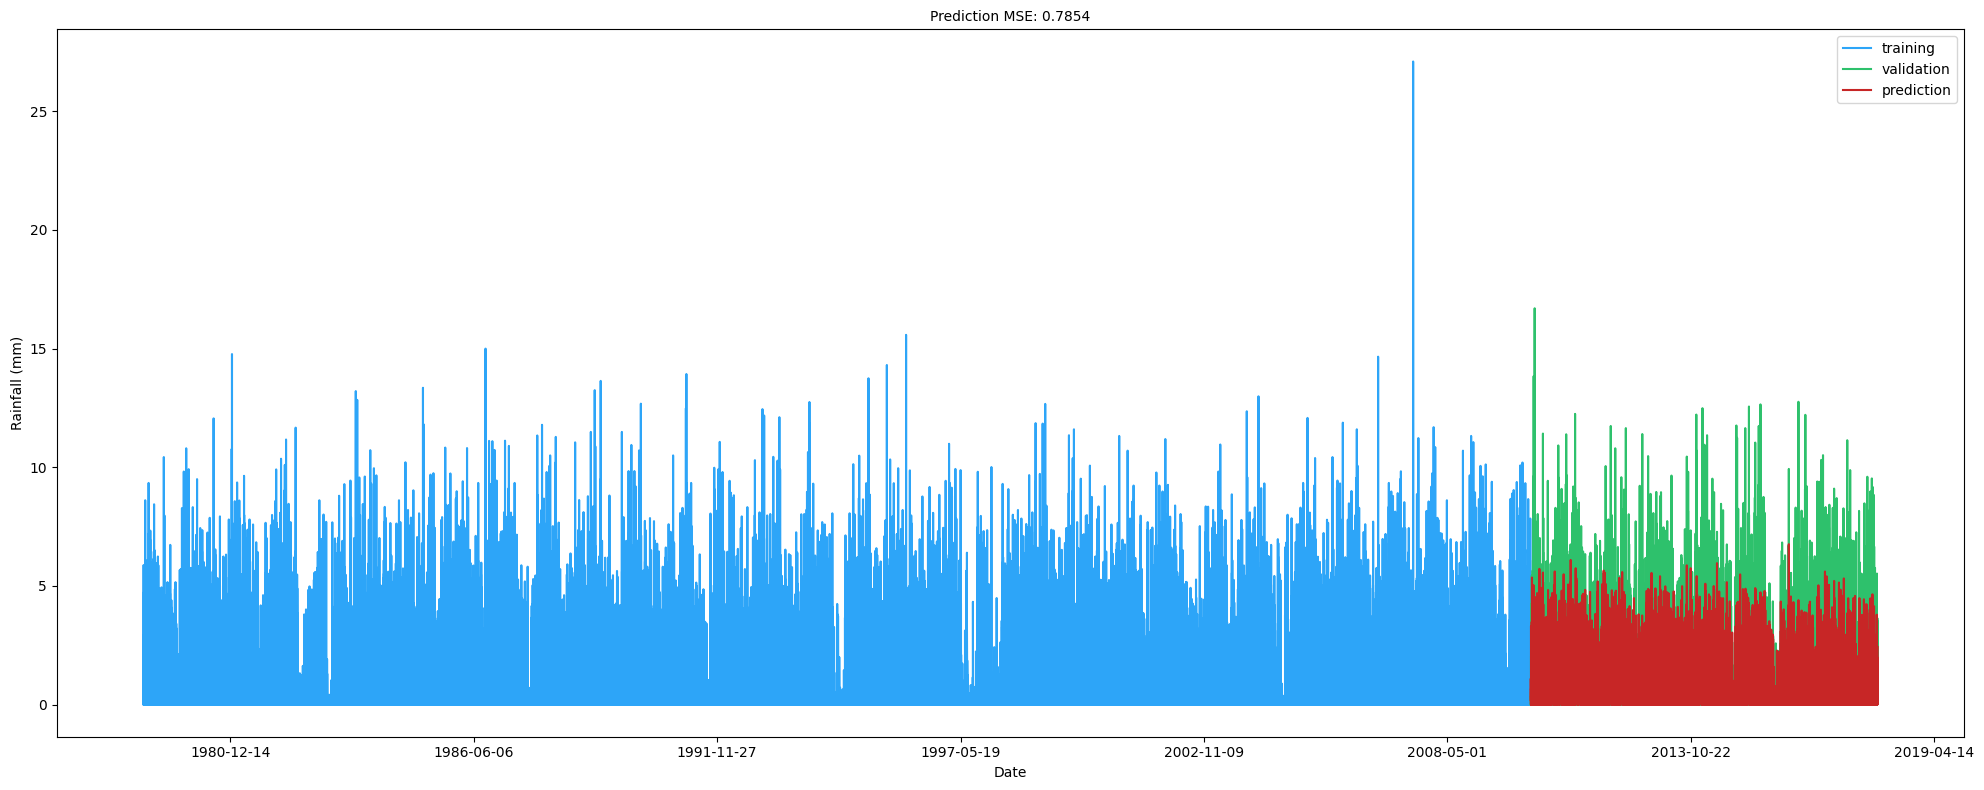

In [30]:
model_lgb = CatBoostRegressor(logging_level="Silent", random_state=42)
model_lgb.fit(X_train, y_train * 1.1, eval_set=[(X_val, y_val)], early_stopping_rounds=100, verbose=200)

val_pred = model_lgb.predict(X_val)
plot_prediction(model_lgb, X, y, tr_diff)

In [31]:
CONST = 5
eval_df = pd.DataFrame({"diff":y_val-val_pred,
                     "actual": y_val.values,
                     "pred": val_pred})
bigger_actual = eval_df[eval_df["diff"] > CONST].shape[0]
bigger_pred = eval_df[eval_df["diff"] < -CONST].shape[0]

print(f"Actual value > {CONST} from Pred:", bigger_actual)
print(f"Pred > {CONST} from Actual value:", bigger_pred)

Actual value > 5 from Pred: 197
Pred > 5 from Actual value: 0


In [112]:
eval_df[eval_df["diff"] > 5]

,diff,actual,pred
269081,8.964066,9.61,0.645934
269153,5.214901,6.02,0.805099
269154,10.689758,11.44,0.750242
269155,13.111392,13.84,0.728608
269156,7.888171,8.73,0.841829
...,...,...,...
334695,6.400991,6.83,0.429009
334863,6.321775,9.16,2.838225
335057,6.412218,8.83,2.417782
335104,5.037702,6.66,1.622298


In [48]:
X_cls = tr_eng.drop(["rain_1h"], axis=1)
y_cls = tr_eng.rain_1h

X_train_cls, X_val_cls, y_train_cls, y_val_cls = ts_train_test(X_cls, y_cls)
classifier = xgb.XGBRegressor(n_estimators=800, max_depth=8, learning_rate=0.08, tree_method="gpu_hist").fit(X_train_cls, y_train_cls,
                                                                                     eval_set=[(X_val_cls, y_val_cls)],
                                                                                     early_stopping_rounds=100,
                                                                                     verbose=100)

pred = classifier.predict(X_val_cls)
np.sqrt(mean_squared_error(y_val_cls, pred))

[0]	validation_0-rmse:0.98830
[100]	validation_0-rmse:0.78796
[200]	validation_0-rmse:0.78657
[252]	validation_0-rmse:0.78658


0.7852015207422779

In [40]:
from sklearn.metrics import recall_score, precision_score

THRESHOLD = 0.75

adj_cls_pred = [2 if arr[2] > THRESHOLD else 0 for arr in classifier.predict_proba(X_val_cls)]
precision_score(y_val_cls, adj_cls_pred, average="macro")

0.47052281382010924

In [46]:
print(classification_report(y_val_cls, adj_cls_pred, target_names=["0", "1", "2"]))

              precision    recall  f1-score   support

           0       0.58      1.00      0.73     38568
           1       0.00      0.00      0.00     24413
           2       0.83      0.07      0.13      4167

    accuracy                           0.58     67148
   macro avg       0.47      0.36      0.29     67148
weighted avg       0.38      0.58      0.43     67148



In [49]:
semi_df = pd.concat([X_val_cls.reset_index(drop=True), 
                     pd.DataFrame({"cls_rain":adj_cls_pred}), 
                     pd.DataFrame({"pred_reg":pred}),
                     tr_eng.loc[268593:][["rain_1h"]].reset_index(drop=True)], axis=1)
semi_df[["cls_rain", "pred_reg", "rain_1h"]]

,cls_rain,pred_reg,rain_1h
0,0,0.027823,0.00
1,0,0.051221,0.00
2,0,0.098984,0.00
3,0,-0.037408,0.00
4,0,0.765375,0.12
...,...,...,...
67143,0,0.065716,0.00
67144,0,0.099554,0.00
67145,0,0.147804,0.00
67146,0,0.179918,0.30


In [55]:
for idx, row in semi_df[["cls_rain", "pred_reg", "rain_1h"]].iterrows():
#     if row["cls_rain"] == 0:
#         semi_df.at[idx, "pred_reg"] =0
    if row["cls_rain"] == 2:
        semi_df.at[idx, "pred_reg2"] = row["pred_reg"] * 1.09
    else:
        semi_df.at[idx, "pred_reg2"] = row["pred_reg"]
        
np.sqrt(mean_squared_error(y_val_cls, semi_df["pred_reg2"]))

0.7848634913053042

## 6. Hyperparameter Tuning

In [38]:
def objective_xgb_reg(trial, data=tr_eng, target_col="rain_1h"):
    
    TARGET_COL = target_col  #  sesuaikan dengan dataset
    param = {
        'lambda': trial.suggest_loguniform('lambda', 1e-3, 5),
        'alpha': trial.suggest_loguniform('alpha', 1e-3, 5),
        'colsample_bytree': trial.suggest_categorical('colsample_bytree', [0.3,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.8,0.9, 1.0]),
        'subsample': trial.suggest_categorical('subsample', [0.4,0.5,0.6,0.7,0.8,1.0]),
        'learning_rate': trial.suggest_categorical('learning_rate', [0.01, 0.013, 0.016, 0.02, 0.025, 0.03, 0.035, 0.04]),
        'n_estimators': 3000,
        'tree_method':"gpu_hist",
        'max_depth': trial.suggest_categorical('max_depth', [4,5,6,7,8,9,10,11,12,13]),
        'random_state': trial.suggest_categorical('random_state', [42]),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 40),
        'gamma': trial.suggest_int('gamma', 0, 10)
    }
    model = xgb.XGBRegressor(**param)
    scores,_ = kfold_cv(model, data, target_col=target_col)
    
    return scores

study_xgb_cls = optuna.create_study(direction='minimize')
study_xgb_cls.optimize(objective_xgb_reg, n_trials=30)
print('Number of finished trials:', len(study_xgb_cls.trials))
print('Best trial:', study_xgb_cls.best_trial.params)

[I 2023-09-21 14:47:38,887] A new study created in memory with name: no-name-a30e4890-b939-421b-ac44-065d242583ac


Fold 1: 0.670881
Fold 2: 0.674847
Fold 3: 0.693990
Fold 4: 0.744754


[I 2023-09-21 14:49:55,300] Trial 0 finished with value: 0.7137131851787977 and parameters: {'lambda': 2.3426717643882444, 'alpha': 4.482676506807982, 'colsample_bytree': 1.0, 'subsample': 1.0, 'learning_rate': 0.025, 'max_depth': 11, 'random_state': 42, 'min_child_weight': 10, 'gamma': 7}. Best is trial 0 with value: 0.7137131851787977.


Fold 5: 0.784094
Mean KFold: 0.713713
Fold 1: 0.664901
Fold 2: 0.669850
Fold 3: 0.687830
Fold 4: 0.735893


[I 2023-09-21 14:52:40,511] Trial 1 finished with value: 0.7063567760657785 and parameters: {'lambda': 1.7214783920162706, 'alpha': 0.9046850521276171, 'colsample_bytree': 1.0, 'subsample': 0.8, 'learning_rate': 0.03, 'max_depth': 10, 'random_state': 42, 'min_child_weight': 39, 'gamma': 4}. Best is trial 1 with value: 0.7063567760657785.


...

Fold 5: 0.782902
Mean KFold: 0.714476
Fold 1: 0.661141
Fold 2: 0.664968
Fold 3: 0.682860
Fold 4: 0.731925


[I 2023-09-21 17:27:12,791] Trial 28 finished with value: 0.702328498056733 and parameters: {'lambda': 0.008785922731451146, 'alpha': 0.3129213104664255, 'colsample_bytree': 0.55, 'subsample': 0.7, 'learning_rate': 0.01, 'max_depth': 9, 'random_state': 42, 'min_child_weight': 17, 'gamma': 1}. Best is trial 14 with value: 0.700604403398611.


Fold 5: 0.770749
Mean KFold: 0.702328
Fold 1: 0.679599
Fold 2: 0.684811
Fold 3: 0.702149
Fold 4: 0.755347


[I 2023-09-21 17:30:31,373] Trial 29 finished with value: 0.7227654783499606 and parameters: {'lambda': 0.016484007079524566, 'alpha': 0.06473975289322154, 'colsample_bytree': 0.7, 'subsample': 1.0, 'learning_rate': 0.025, 'max_depth': 4, 'random_state': 42, 'min_child_weight': 40, 'gamma': 5}. Best is trial 14 with value: 0.700604403398611.


Fold 5: 0.791921
Mean KFold: 0.722765
Number of finished trials: 30
Best trial: {'lambda': 0.004360442203388971, 'alpha': 0.04899593385279265, 'colsample_bytree': 0.45, 'subsample': 0.8, 'learning_rate': 0.01, 'max_depth': 12, 'random_state': 42, 'min_child_weight': 32, 'gamma': 0}


In [1]:
kfold_cv(XGBRegressor(**{'lambda': 0.8843807912728843, 'alpha': 4.7651535785080315, 'colsample_bytree': 0.6, 
                         'subsample': 1.0, 'learning_rate': 0.025, 'max_depth': 9, 'random_state': 42,'n_estimators':2000, 
                         'min_child_weight': 24, 'gamma': 0, 'tree_method':'gpu_hist'}),
        tr_eng, const=1.0, verbose=500)

NameError: name 'kfold_cv' is not defined

In [68]:
ts_eng = ts_eng.drop(["rain_1h"], axis=1)
tr_eng = tr_eng[tr_eng["rain_1h"] >= 0]

In [25]:
final_best_params = {'lambda': 0.8843807912728843, 'alpha': 4.7651535785080315, 'colsample_bytree': 0.6, 
                         'subsample': 1.0, 'learning_rate': 0.020, 'max_depth': 9, 'random_state': 42,'n_estimators':2300, 
                         'min_child_weight': 15, 'gamma': 0, 'tree_method':'gpu_hist'}

final_model = XGBRegressor(**final_best_params).fit(tr_eng.drop(["rain_1h"], axis=1),
                           tr_eng.rain_1h)

In [26]:
tr_eng.to_csv("train_data_xgb_threelayers.csv", index=False)

In [41]:
0.2 * tr_eng.shape[0]

67148.2

## Submission

In [27]:
submission = pd.read_csv("/kaggle/input/tahap-penyisihan-oq-dataquestua/sample_submission.csv")
submission

,datetime_iso,rain_1h
0,2018-01-01 00:00:00+00:00,0
1,2018-01-01 01:00:00+00:00,0
2,2018-01-01 02:00:00+00:00,0
3,2018-01-01 03:00:00+00:00,0
4,2018-01-01 04:00:00+00:00,0
...,...,...
49363,2023-08-19 19:00:00+00:00,0
49364,2023-08-19 20:00:00+00:00,0
49365,2023-08-19 21:00:00+00:00,0
49366,2023-08-19 22:00:00+00:00,0


In [34]:
tr_eng.shape, ts_eng.shape

((335765, 339), (49356, 339))

In [37]:
ts_pred_proba = model_cls.predict_proba(ts_eng)

In [38]:
TS_THRESHOLD = 0.80

adj_ts_cls = pd.Series([1 if arr[2] > TS_THRESHOLD else 0 for arr in ts_pred_proba])
adj_ts_cls.value_counts()

0    49114
1      254
Name: count, dtype: int64

In [83]:
ts_eng

,temp,d_point,feels,min_temp_real,max_temp_real,prssr,hum,clouds,min_temp_lb10,min_d_point_lb10,min_prssr_lb10,min_hum_lb10,min_wind_spd_lb10,min_wind_deg_lb10,min_clouds_lb10,max_temp_lb10,max_d_point_lb10,max_prssr_lb10,max_hum_lb10,max_wind_spd_lb10,max_wind_deg_lb10,max_clouds_lb10,mean_temp_lb10,mean_d_point_lb10,mean_prssr_lb10,mean_hum_lb10,mean_wind_spd_lb10,mean_wind_deg_lb10,mean_clouds_lb10,var_temp_lb10,var_d_point_lb10,var_prssr_lb10,var_hum_lb10,var_wind_spd_lb10,var_wind_deg_lb10,var_clouds_lb10,ptp_temp_lb10,ptp_d_point_lb10,ptp_prssr_lb10,ptp_hum_lb10,ptp_wind_spd_lb10,ptp_wind_deg_lb10,ptp_clouds_lb10,p1_temp_lb10,p1_d_point_lb10,p1_prssr_lb10,p1_hum_lb10,p1_wind_spd_lb10,p1_wind_deg_lb10,p1_clouds_lb10,p2_temp_lb10,p2_d_point_lb10,p2_prssr_lb10,p2_hum_lb10,p2_wind_spd_lb10,p2_wind_deg_lb10,p2_clouds_lb10,p3_temp_lb10,p3_d_point_lb10,p3_prssr_lb10,p3_hum_lb10,p3_wind_spd_lb10,211.0,-24.0,211.0,-28.0,211.0,-28.0,211.0,-28.0,211.0,-11.0,211.0,-11.0,211.0,17.0,87.0,17.0,87.0,17.0,87.0,3.0,87.0,3.0,87.0,3.0,87.0,-11.0,87.0,-11.0,87.0,-1.825766,-1.097031,8,231,3,23


In [39]:
import math

# new_cols = [i.replace("_real", "") if (len(i.split("_")) == 4 and "diff" not in i) or (len(i.split("_")) == 5) else i for i in ts_eng_fix.columns]
# ts_eng_fix.columns = new_cols
test_pred = final_model.predict(ts_eng)
test_pred = [max(0, i) for i in test_pred]

In [40]:
ts_post = postprocessing(adj_ts_cls, pd.Series(test_pred), actual=pd.Series([i for i in range(len(adj_ts_cls))]), const=1.05)

Before postprocessing: 28501.838995375798
After postprocessing: 28501.838003198158


In [52]:
len(test_pred), len(submission)

(49368, 49368)

In [42]:
ts_post.describe()

,pred_cls,pred_reg,actual,adj_pred_reg
count,49368.000000,49368.000000,49368.000000,49368.000000
mean,0.005145,0.402319,24683.500000,0.403415
std,0.071545,0.608961,14251.458382,0.616264
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.047944,12341.750000,0.047944
50%,0.000000,0.184698,24683.500000,0.184698
75%,0.000000,0.494530,37025.250000,0.494530
max,1.000000,6.888594,49367.000000,7.233023


In [41]:
ori_ts_data

datetime               datetime_iso  time-zone           temp  \
0      1514764800  2018-01-01 00:00:00+00:00      28800       26.59 °C   
1      1514768400  2018-01-01 01:00:00+00:00      28800        26.51 C   
2      1514772000  2018-01-01 02:00:00+00:00      28800       28.68  C   
3      1514775600  2018-01-01 03:00:00+00:00      28800        28.84 C   
4      1514779200  2018-01-01 04:00:00+00:00      28800  29.75 Celcius   
...           ...                        ...        ...            ...   
49363  1692471600  2023-08-19 19:00:00+00:00      28800        24.37 C   
49364  1692475200  2023-08-19 20:00:00+00:00      28800        23.87 C   
49365  1692478800  2023-08-19 21:00:00+00:00      28800  23.87 Celcius   
49366  1692482400  2023-08-19 22:00:00+00:00      28800        23.87°C   
49367  1692486000  2023-08-19 23:00:00+00:00      28800        26.57 C   

      visibility   d_point     feels min_temp  max_temp        prssr  \
0            NaN     23.66     26.59    26.02     27.16         1009   
1            NaN     24.92  26.51 °C    26.06     28.04         1009   
2            NaN     25.71     34.68  28.03 C    29.3 C  1009.0 hPa.   
3            NaN     25.25     34.51    28.52  29.08 °C         1008   
4                    24.62     35.38  29.31 C     30.57         1007   
...          ...       ...       ...      ...       ...          ...   
49363        NaN     23.34     25.32   22.7°C   28.2 °C   1011.0 hPa   
49364        NaN     23.02   24.79 C    21.91  28.01 °C         1011   
49365        NaN     23.02     24.79    21.91     28.01         1011   
49366  undefined     23.02     24.79    21.91  28.01 °C    1011.0hPa   
49367        NaN  22.42  C   26.57 C    25.55     27.85         1012   

          sea_level    grnd_level     hum  wind_spd wind_deg      rain_3h  \
0               NaN  undetermined      84  1.45 m/s      355            0   
1               NaN  undetermined      91  1.67 m/s      351          0mm   
2               NaN           NaN      84  1.72 m/s   345.0°         0 mm   
3               NaN           NaN      81      1.49   339.0°  0 milimeter   
4      undetermined  undetermined      74  1.39 m/s   339.0°          NaN   
...             ...           ...     ...       ...      ...          ...   
49363           NaN  not-recorded      94      1.57   239.0°          NaN   
49364  undetermined  undetermined      95      1.53   235.0°            0   
49365           NaN       unknown  95.00%  1.53 m/s      235          NaN   
49366  undetermined           NaN  95.00%      1.53      235          NaN   
49367           NaN           NaN      78  2.13 m/s   211.0°          NaN   

           snow_1h      snow_3h  clouds  
0              NaN      no_snow      97  
1          no-snow  0 milimeter      95  
2      volume:zero            0      90  
3                0          NaN      91  
4                0     volume:0      96  
...            ...          ...     ...  
49363      no_snow            0      84  
49364          NaN            0      70  
49365          NaN          NaN      70  
49366            0          NaN  70.00%  
49367            0          NaN      87  

[49368 rows x 19 columns]

In [42]:
ts_eng.tail(10)

,temp,d_point,feels,min_temp_real,max_temp_real,prssr,hum,clouds,diff_temp,min_temp_lb12,min_diff_temp_lb12,min_d_point_lb12,min_prssr_lb12,min_hum_lb12,min_wind_spd_lb12,min_wind_deg_lb12,min_clouds_lb12,max_temp_lb12,max_diff_temp_lb12,max_d_point_lb12,max_prssr_lb12,max_hum_lb12,max_wind_spd_lb12,max_wind_deg_lb12,max_clouds_lb12,mean_temp_lb12,mean_diff_temp_lb12,mean_d_point_lb12,mean_prssr_lb12,mean_hum_lb12,mean_wind_spd_lb12,mean_wind_deg_lb12,mean_clouds_lb12,var_temp_lb12,var_diff_temp_lb12,var_d_point_lb12,var_prssr_lb12,var_hum_lb12,var_wind_spd_lb12,var_wind_deg_lb12,var_clouds_lb12,ptp_temp_lb12,ptp_diff_temp_lb12,ptp_d_point_lb12,ptp_prssr_lb12,ptp_hum_lb12,ptp_wind_spd_lb12,ptp_wind_deg_lb12,ptp_clouds_lb12,p10_temp_lb12,p10_diff_temp_lb12,p10_d_point_lb12,p10_prssr_lb12,p10_hum_lb12,p10_wind_spd_lb12,p10_wind_deg_lb12,p10_clouds_lb12,p20_temp_lb12,p20_diff_temp_lb12,p20_d_point_lb12,p20_prssr_lb12,p20_hum_lb12,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000


In [43]:
submission["rain_1h"] = ts_post["adj_pred_reg"]
submission.loc[ts_eng.loc[ts_eng.clouds < 10].index, 'rain_1h'] = 0
submission.loc[ts_eng.loc[ts_eng.hum < 50].index, 'rain_1h'] = 0

In [46]:
submission.to_csv("submission10_ghana.csv", index=False)

In [31]:
submission[submission["rain_1h"] <0]

,datetime_iso,rain_1h


In [45]:
submission.describe()

,rain_1h
count,49368.000000
mean,0.403105
std,0.616431
min,0.000000
25%,0.047343
50%,0.184522
75%,0.494505
max,7.233023


In [97]:
ts_post[["adj_pred_reg"]].describe()

,adj_pred_reg
count,49368.000000
mean,0.404138
std,0.629606
min,0.000000
25%,0.047648
50%,0.178724
75%,0.488459
max,7.168788


In [33]:
import pickle

# save the iris classification model as a pickle file
model_pkl_file = "xgb_model.pkl"  

with open(model_pkl_file, 'wb') as file:  
    pickle.dump(final_model, file)

In [69]:
ts_eng.to_csv("test_data_threelayers.csv", index=False)

In [ ]:
final_model.to_pickle